## Imports

In [4]:
import karateclub as kc
import matplotlib.pyplot as plt
import networkx as nx
from networkx.drawing.nx_pydot import graphviz_layout
import numpy as np
import os
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import pydot
import random
import warnings

from collections import defaultdict
from plotly.subplots import make_subplots
from reeb_utils import all_traj_same, collapse_traj, do_reeb_for_df, plot_treeb, plot_treeb_special_path
# do_reeb_for_start_end, do_reeb_for_explore_node, plot_treeb
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics.cluster import adjusted_rand_score, normalized_mutual_info_score
from sklearn.model_selection import train_test_split


warnings.filterwarnings("ignore")
pd.options.mode.chained_assignment = None

## Load data

In [5]:
# load data into dataframe
df = pd.read_csv("data/MLINDIV_train_full.csv")

test_df = df[df["eprocs"].str.contains("Test")]

test_df["subj_mean_acc"] = test_df.groupby("Subject")["accuracy"].transform("mean")
test_df["path_mean_acc"] = test_df.groupby(["StartAt", "EndAt"])["accuracy"].transform("mean")

test_df['quartile'] = (
    pd.qcut(test_df['subj_mean_acc'], 4, labels=[1, 2, 3, 4])
)

test_df["path_mean_acc_by_Q"] = test_df.groupby(["StartAt", "EndAt", "quartile"])["accuracy"].transform("mean")

# # Calculate min path dist; first set v high for the wrong people
# # Note: there's definitely a smarter way to do this in pandas
# test_df["fake_dist"] = test_df["trajs"].apply(len)
# test_df.loc[~test_df["accuracy"], "fake_dist"] = 999

# test_df["min_dist"] = test_df.groupby("StartEnd")["fake_dist"].transform("min")

## Try to predict individual success from location on Flow Tree

The thought is to create a Flow Tree with 70% of the data, will you be able to predit if an indiidual gets it right or wrong depending on where they are on the Flow Tree **before they finish**

### Util fns for indiv thru flow tree

In [6]:
def track_indiv_through_flow_tree(this_df, special_subject_number, use_turns=True, DEBUG=False):
    # Check that all of the start nodes are the same
    assert len(set(this_df["StartAt"])) == 1
    
    trajs = []
    accs = []
    count = 0
    indiv_idx = None
    for _, row in this_df.iterrows():
        # print(row["Subject"], special_subject_number, row["Subject"] == special_subject_number)
        if row["Subject"] == special_subject_number:
            indiv_idx = count
        path = row["e_paths"] if use_turns else row["paths"]
        if path[-2:] == "NA": path = path[:-2] # this happens if the test ends unsuccessfully
        
        states = path.split()
        if not use_turns: states = collapse_traj(states)
        trajs.append(states)
        accs.append(row["accuracy"])
        count += 1
        # if count == 15: break
    assert indiv_idx is not None
    
    visited = {}

    G = nx.Graph()
    G.add_node(start_node + "_0", color="red", end=False)

    special_visits = [start_node + "_0"]
    likelihoods_by_level = []
    track_indiv_generate_reeb_tree(0, start_node, trajs, [i for i in range(len(trajs))], G, visited, accs, special_visits=special_visits, likelihoods_by_level=likelihoods_by_level, special_idx=indiv_idx, SUCCESS=end_node[0], DEBUG=DEBUG)
    
    return G, special_visits, likelihoods_by_level

def track_indiv_generate_reeb_tree(start_i, start_node, trajs, which_trajs, G, visited, accs, special_visits=[], likelihoods_by_level=[], special_idx=-1, SUCCESS="", DEBUG=False):
    """Generates Reeb tree.

    TODO talk about what this means

    Parameters
    ----------
    start_i : TODO,
        TODO
    start_node : TODO,
        TODO
    trajs : list,
        Shape = [n_trajs, various]
        List of all trajectories over which to compute the Reeb tree.
    G : nx.Graph,
        Reeb tree to mutate in place as graph is construted.
    visited : TODO,
        TODO
    DEBUG : boolean,
        If True print more things.

    Returns
    -------
    None
    """
    if DEBUG: print(f"DO REEB, {start_i}, {start_node}, {which_trajs}")
    times_before = visited.get(start_node, 0) 
    visited[start_node] = times_before
    to_add = start_node + "_" + str(times_before)

    max_traj_len = max([len(trajs[t]) for t in which_trajs])

    ## BASE CASE 1: SINGLETON ##
    ## BASE CASE 2: ALL THE SAME ##
    if len(which_trajs) == 1 or all_traj_same(trajs, which_trajs, max_traj_len):
        end_node = trajs[which_trajs[0]][-1]
        times_before = visited.get(end_node, -1) + 1
        visited[end_node] = times_before
        
        end_node +=  "_" + str(times_before)
        if DEBUG: print(f"BASE CASE: {which_trajs}, last: {end_node}")

        color = "green" if SUCCESS in end_node else "yellow"
        G.add_node(end_node, color=color, end=True)
        G.add_edge(to_add, end_node, weight=len(which_trajs))


        if special_idx in which_trajs and len(which_trajs) > 1:
            if DEBUG: print("IN BC", special_idx, which_trajs)
            special_visits.append(end_node)
            likelihood = np.mean([accs[z] for z in which_trajs[:-1]])
            likelihoods_by_level.append(likelihood)
            if DEBUG: print(special_visits)

        return
    

    ## RECURSIVE STEP ##
    if DEBUG: print(f"FOR LOOP, {start_i}, {which_trajs}")
    for step in range(start_i, max_traj_len):
        
        new_gn = {}
        for i in which_trajs:
            traj = trajs[i]

            ## STOPPING CONDITION FOR THIS ONE GUY ##
            if step >= len(traj): 
                new_gn["DONE"] = new_gn.get("DONE", []).copy() + [i]
            else:
                new_node = traj[step]     
                new_gn[new_node] = new_gn.get(new_node, []).copy() + [i]

        if DEBUG: print("NEW_GN", new_gn)
        # decide whether we need a reeb node
        
        # people went different ways!!
        if len(new_gn.keys()) > 1:
            times_before = visited.get(start_node, 0)
            sn = start_node + "_" + str(times_before)
            
            # the thing happened at the node before this! all the paths in this fn are at the same point there so it doesnt mattter
            old_one = trajs[which_trajs[0]][step-1]
            times_before = visited.get(old_one, -1) + 1
            visited[old_one] = times_before
            
            on = old_one + "_" + str(times_before)
            G.add_node(on, color="blue", end=False)
            if DEBUG: print(f"ADDING NEW BLUE NODE {on}")
            
            G.add_edge(sn, on, weight=len(which_trajs))
            if DEBUG: print(f"ADDING NEW EDGE from {sn} to {on}, weight is {len(which_trajs)}")

            if special_idx in which_trajs:
                if DEBUG: print("IN RECURSE", special_idx, which_trajs)
                special_visits.append(on)
                likelihood = np.mean([accs[z] for z in which_trajs[:-1]])
                likelihoods_by_level.append(likelihood)
                if DEBUG: print(special_visits)
            
            for k, v in new_gn.items():
                if DEBUG: print("RECURSE")
                if DEBUG and k == "DONE":
                    print("*@#)$*$#()*(#@($")
                    print(new_gn)
                track_indiv_generate_reeb_tree(step+1, old_one, trajs,  v, G, visited, accs, special_visits=special_visits, likelihoods_by_level=likelihoods_by_level, special_idx=special_idx, SUCCESS=SUCCESS, DEBUG=DEBUG)

            return

### Do indiv predictions one Flow Tree

A_0 G_0 {'weight': 55} blue
G_0 H_0 {'weight': 44} blue
G_0 L_0 {'weight': 11} blue
H_0 Q_0 {'weight': 32} blue
H_0 B_0 {'weight': 12} blue
Q_0 T_0 {'weight': 21} blue
Q_0 R_0 {'weight': 11} blue
T_0 X_0 {'weight': 20} blue
X_0 Y_0 {'weight': 19} green
X_0 T_1 {'weight': 1} yellow
T_1 P_0 {'weight': 1} yellow
R_0 U_0 {'weight': 7} blue
R_0 O_0 {'weight': 2} blue
R_0 J_0 {'weight': 2} blue
U_0 X_1 {'weight': 6} blue
U_0 W_0 {'weight': 1} yellow
X_1 Y_1 {'weight': 5} blue
X_1 P_1 {'weight': 1} yellow
Y_1 V_0 {'weight': 1} yellow
Y_1 Y_2 {'weight': 4} green
O_0 M_0 {'weight': 1} yellow
O_0 O_1 {'weight': 1} yellow
J_0 N_0 {'weight': 1} yellow
J_0 K_0 {'weight': 1} yellow
B_0 Q_1 {'weight': 3} blue
B_0 C_0 {'weight': 9} blue
Q_1 H_1 {'weight': 1} yellow
Q_1 Y_3 {'weight': 2} green
C_0 D_0 {'weight': 8} blue
C_0 X_2 {'weight': 1} yellow
D_0 E_0 {'weight': 4} blue
D_0 J_1 {'weight': 4} blue
E_0 S_0 {'weight': 2} blue
E_0 S_2 {'weight': 2} blue
S_0 O_2 {'weight': 1} yellow
S_0 S_1 {'weight': 

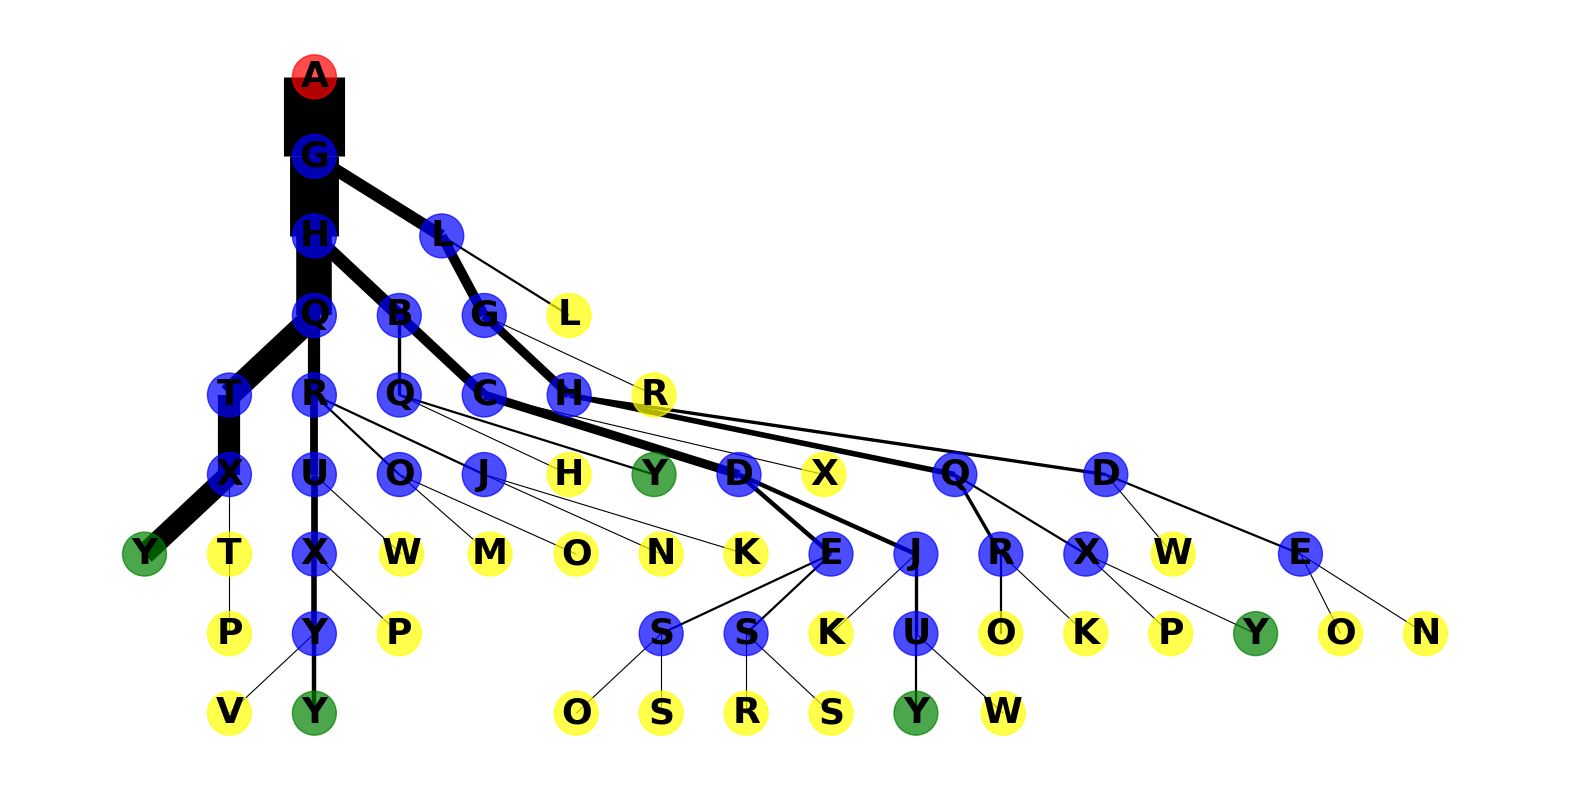

In [17]:
G = G_plus_one
fig = plt.figure(figsize=(20,10))
this_ax = plt.gca()

pos = graphviz_layout(G, prog="dot")

edges = G.edges()
# colors = [G[u][v]['color'] for u,v in edges]
weights = [G[u][v]['weight'] * .8 for u,v in edges]

nodes = G.nodes()
# for n in nodes:
#     print(n, G.nodes[n])
n_labels = {n: n[:-2] for n in G}
n_colors = [G.nodes[n].get("color", "blue") for n in nodes]
# print(n_colors)
# print ((q-1) // 2, (q-1) % 2)
nx.draw_networkx_nodes(G, pos, node_color=n_colors, node_size=1000, alpha=0.7, ax=this_ax)
nx.draw_networkx_edges(G, pos, edgelist=edges, width=weights, ax=this_ax)
nx.draw_networkx_labels(G, pos, labels=n_labels, font_size=26, font_weight="bold", ax=this_ax)

this_ax.axis("off")

for u,v in edges:
    print(u, v, G[u][v], G.nodes[v].get("color", "blue"))
    

Individual subject #110 got it wrong.
Their trajectory: A G H Q R U T X T Q
Likelihoods by level: [0.5185185185185185, 0.6136363636363636, 0.71875, 0.36363636363636365, 0.5714285714285714, 0.6666666666666666]


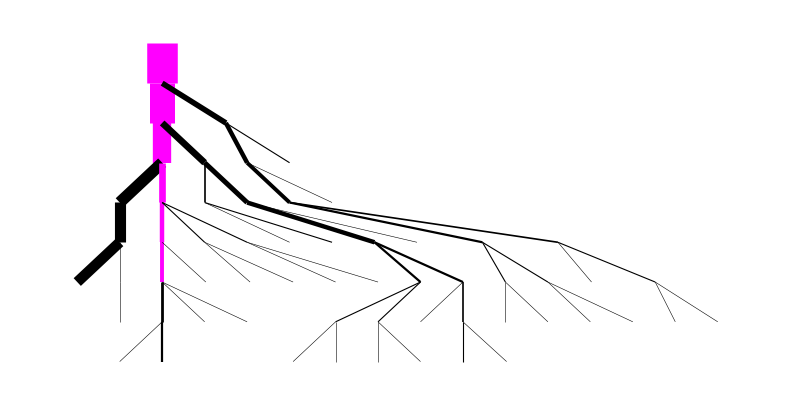

Individual subject #103 got it right.
Their trajectory: A G H Q T X V Y
Likelihoods by level: [0.5185185185185185, 0.6136363636363636, 0.71875, 0.9047619047619048, 0.95, 1.0]


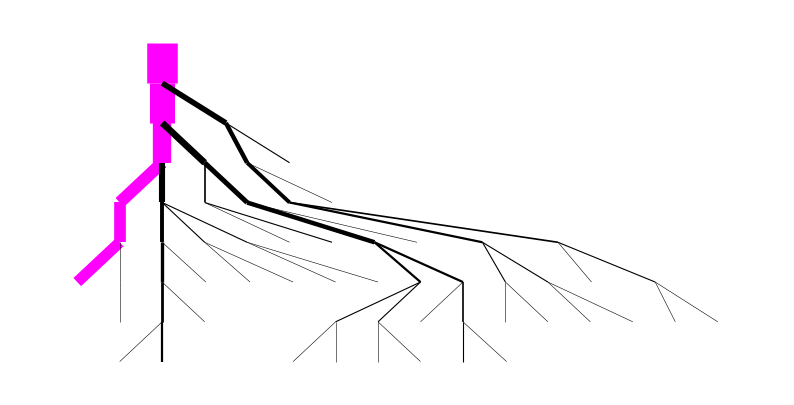

Individual subject #59 got it right.
Their trajectory: A G H Q T X V Y
Likelihoods by level: [0.5185185185185185, 0.6136363636363636, 0.71875, 0.9047619047619048, 0.95, 1.0]


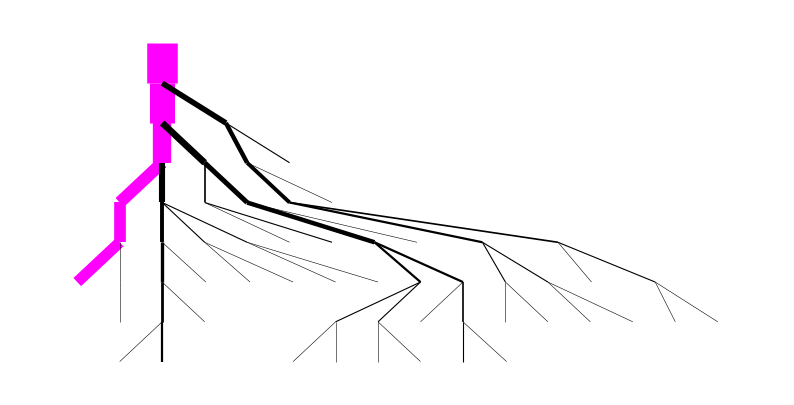

Individual subject #50 got it wrong.
Their trajectory: A G H Q R J K
Likelihoods by level: [0.5185185185185185, 0.6136363636363636, 0.71875, 0.36363636363636365, 0.0, 0.0]


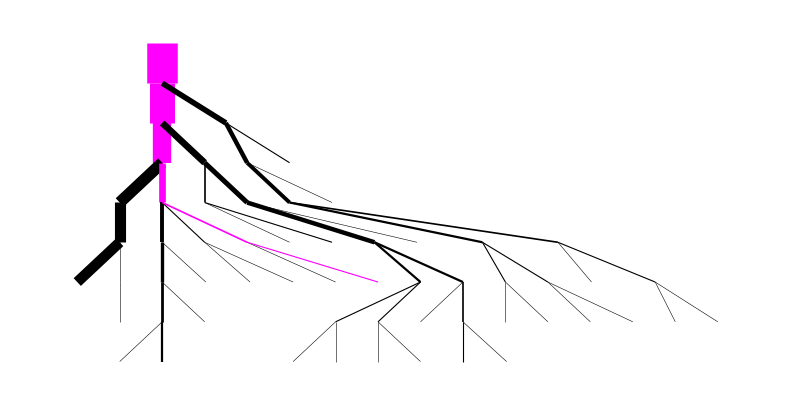

Individual subject #30 got it wrong.
Their trajectory: A G H Q R J K
Likelihoods by level: [0.5185185185185185, 0.6136363636363636, 0.71875, 0.36363636363636365, 0.0, 0.0]


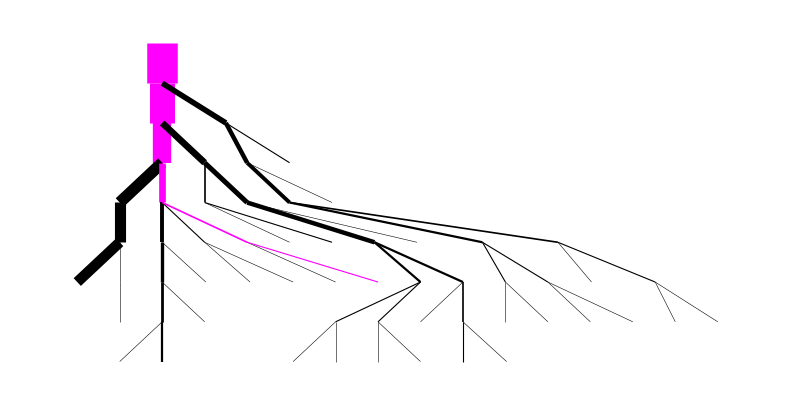

Individual subject #83 got it right.
Their trajectory: A G H B C D J R U T X V Y
Likelihoods by level: [0.5185185185185185, 0.6136363636363636, 0.3333333333333333, 0.2222222222222222, 0.25, 0.5, 0.6666666666666666, 1.0]


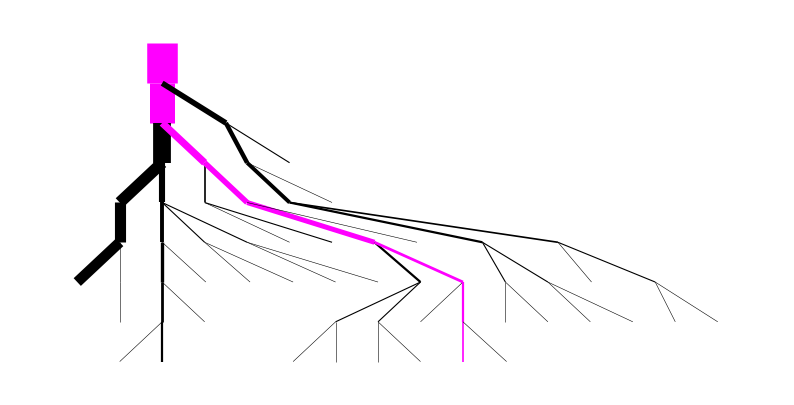

Individual subject #84 got it right.
Their trajectory: A G H Q T X V Y
Likelihoods by level: [0.5185185185185185, 0.6136363636363636, 0.71875, 0.9047619047619048, 0.95, 1.0]


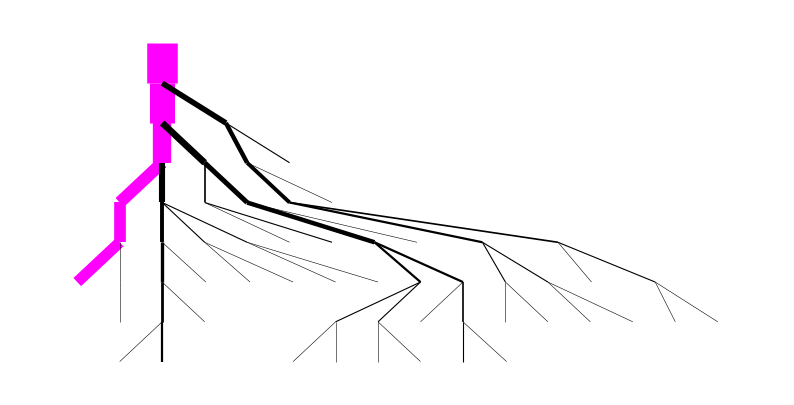

Individual subject #68 got it right.
Their trajectory: A G H Q T X V Y
Likelihoods by level: [0.5185185185185185, 0.6136363636363636, 0.71875, 0.9047619047619048, 0.95, 1.0]


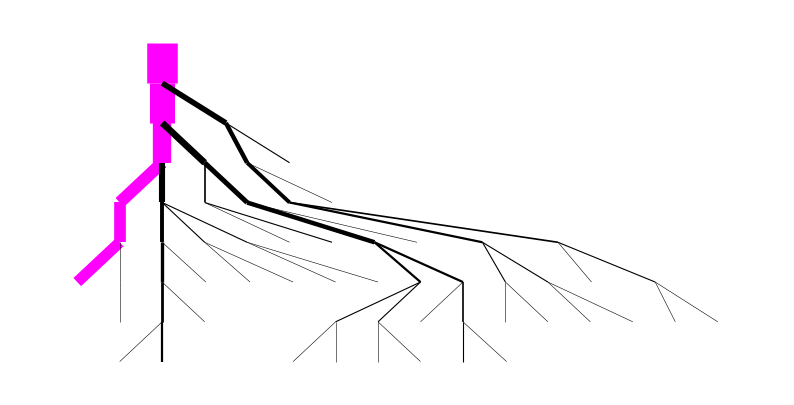

Individual subject #15 got it right.
Their trajectory: A G H Q T X V Y
Likelihoods by level: [0.5185185185185185, 0.6136363636363636, 0.71875, 0.9047619047619048, 0.95, 1.0]


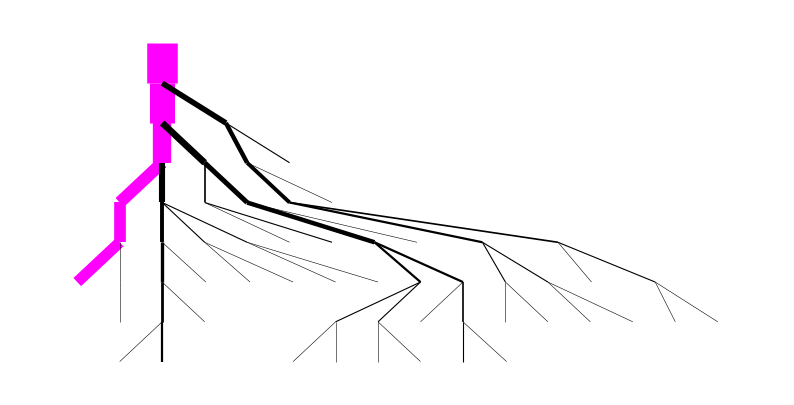

Individual subject #67 got it wrong.
Their trajectory: A G L G H Q R S M O
Likelihoods by level: [0.5185185185185185, 0.1, 0.125, 0.14285714285714285, 0.25, 0.0, 0.0]


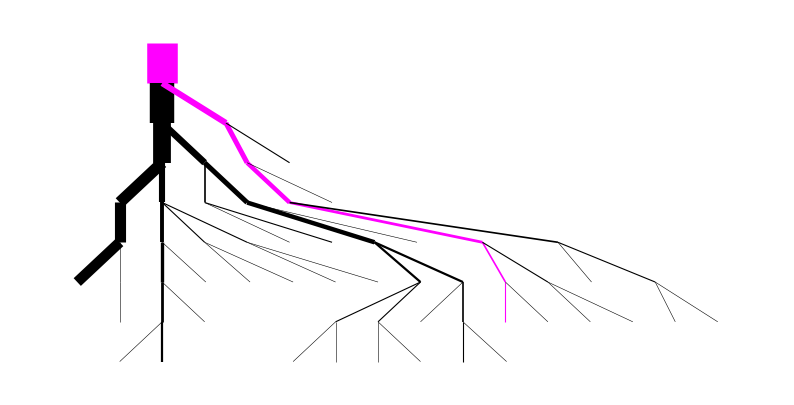

In [9]:
start_node, end_node = "A", "Y"

this_path_df = df[(df["StartAt"] == start_node) & (df["EndAt"] == end_node)]
train_this_path_df, test_this_path_df = train_test_split(this_path_df, test_size=0.2, random_state=6)

count, how_many_to_plot = 0, 10
    
# Identify where one person's path is through the Flow Tree
for _, plus_one in test_this_path_df.iterrows():
    special_subject_number = plus_one["Subject"]

    train_this_path_df_plus_one = pd.concat([train_this_path_df, pd.DataFrame([plus_one])])
    G_plus_one, special_visits, likelihoods_by_level = track_indiv_through_flow_tree(train_this_path_df_plus_one, special_subject_number, use_turns=False, DEBUG=False)

    print(f"Individual subject #{special_subject_number} got it {'right' if plus_one['accuracy'] else 'wrong'}.")
    print("Their trajectory:", " ".join(collapse_traj(plus_one["paths"].split())))
    print("Likelihoods by level:", likelihoods_by_level)

    special_edges = [(special_visits[sv-1], special_visits[sv]) for sv in range(1, len(special_visits))]
    plot_treeb_special_path(G_plus_one, special_edges)#, with_nodes=True)

    count += 1
    if count == how_many_to_plot:
        break

### ROC curve for one Flow Tree

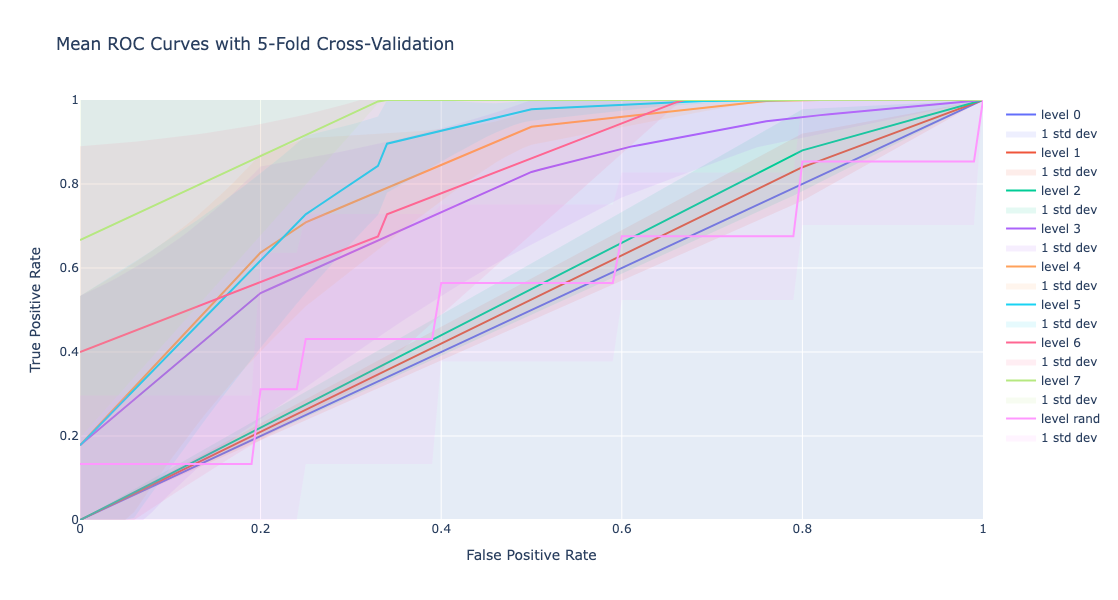

In [162]:
start_node, end_node = "N", "A"

count = 0
plot_xs = []
plot_ys = []

k_likelihoods_by_level_by_person = defaultdict(list)
k_actual_accuracies_by_level_by_person = defaultdict(list)

this_path_df = df[(df["StartAt"] == start_node) & (df["EndAt"] == end_node)]

# Do each Flow Tree k=5 times
for k in range(5):
    likelihoods_by_level_by_person = defaultdict(list)
    actual_accuracies_by_level_by_person = defaultdict(list)

    train_this_path_df, test_this_path_df = train_test_split(this_path_df, test_size=0.2, random_state=k)

    # Identify where one person's path is through the Flow Tree
    for _, plus_one in test_this_path_df.iterrows():
        special_subject_number = plus_one["Subject"]

        train_this_path_df_plus_one = pd.concat([train_this_path_df, pd.DataFrame([plus_one])])
        G_plus_one, special_visits, likelihoods_by_level = track_indiv_through_flow_tree(train_this_path_df_plus_one, special_subject_number, use_turns=False, DEBUG=False)

        # print(f"Individual subject #{special_subject_number} got it {'right' if plus_one['accuracy'] else 'wrong'}.")
        # print("Their trajectory:", " ".join(collapse_traj(plus_one["paths"].split())))
        # print("Likelihoods by level:", likelihoods_by_level)

        # Keep track of all of the predictions for all the levels
        actual_acc = int(plus_one["accuracy"])
        for lvl, lik in enumerate(likelihoods_by_level):
            likelihoods_by_level_by_person[lvl].append(lik)
            actual_accuracies_by_level_by_person[lvl].append(actual_acc)

    for lvl in likelihoods_by_level_by_person:
        k_likelihoods_by_level_by_person[lvl].append(likelihoods_by_level_by_person[lvl])
        k_actual_accuracies_by_level_by_person[lvl].append(actual_accuracies_by_level_by_person[lvl])
       
# Add random
k_likelihoods_by_level_by_person["rand"] = [[random.random() for _ in each_kfold] for each_kfold in k_actual_accuracies_by_level_by_person[0]]
k_actual_accuracies_by_level_by_person["rand"] = k_actual_accuracies_by_level_by_person[0][:]


# print("Predictions:", k_likelihoods_by_level_by_person)
# print("Answers:", k_actual_accuracies_by_level_by_person)

### Compute and plot ROC curve for ONE Flow Tree ###
fig = go.Figure()

roc_data = {}
cs = ['#636EFA', '#EF553B', '#00CC96', '#AB63FA', '#FFA15A', '#19D3F3', '#FF6692', '#B6E880', '#FF97FF', '#FECB52']
ci = 0
for lvl in k_likelihoods_by_level_by_person:

    # Store ROC values for each level to compute mean and thresholds
    tprs = []
    aucs = []
    mean_fpr = np.linspace(0, 1, 101)

    for y_prob, y_test in zip(k_likelihoods_by_level_by_person[lvl], k_actual_accuracies_by_level_by_person[lvl]):
    
        # gonna be illegal to do ROC
        if len(y_test) == 0 or len(set(y_test)) == 1:
            continue

        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc = roc_auc_score(y_test, y_prob)
        aucs.append(roc_auc)

        # Interpolate TPRs over the mean FPR
        tpr_interp = np.interp(mean_fpr, fpr, tpr)
        tprs.append(tpr_interp)

    if len(tprs) == 0: continue

    # print(aucs)
    # print(tprs)
    # Calculate the mean and standard deviation of the TPRs
    mean_tpr = np.mean(tprs, axis=0)
    std_tpr = np.std(tprs, axis=0)

    # Calculate the upper and lower bounds of the shaded area (mean ± 1 std dev)
    tpr_upper = np.minimum(mean_tpr + std_tpr, 1)
    tpr_lower = np.maximum(mean_tpr - std_tpr, 0)   

    # print(mean_tpr)
    # print(mean_fpr)

    # Plot mean ROC curve
    fig.add_trace(go.Scatter(
        x=mean_fpr, y=mean_tpr,
        mode='lines',
        line=dict(color=cs[ci], width=2),
        name=f"level {lvl}"
    ))

    # Plot the shadow (error band)
    fig.add_trace(go.Scatter(
        x=np.concatenate([mean_fpr, mean_fpr[::-1]]),
        y=np.concatenate([tpr_upper, tpr_lower[::-1]]),
        fill='toself',
        opacity=0.1,
        fillcolor=cs[ci],
        line=dict(color='rgba(255,255,255,0)'),
        hoverinfo="skip",
        name='1 std dev'
    ))

    ci += 1

    # Add AUC as annotation
    # mean_auc = np.mean(aucs)
    # fig.add_annotation(x=0.7, y=0.3, text=f"Mean AUC = {mean_auc:.2f}", showarrow=False)

# Customize layout
fig.update_layout(
    title="Mean ROC Curves with 5-Fold Cross-Validation",
    xaxis_title="False Positive Rate",
    yaxis_title="True Positive Rate",
    xaxis=dict(range=[0, 1]),
    yaxis=dict(range=[0, 1]),
    showlegend=True,
    width=800,
    height=600
)
    
# Show plot
fig.show()

    

# # Create an interactive ROC plot using Plotly
# fig = go.Figure()

# # Add ROC curves for each model
# for model_name, (fpr, tpr, auc) in roc_data.items():
#     fig.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name=f'{model_name} (AUC = {auc:.2f})'))#, row=row, col=col)    # Add ROC curves to the respective subplot
            
# # Add a diagonal reference line (random guess line)
# fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', line=dict(dash='dash'), name='Random Guess'))#, row=row, col=col)
    
# # Customize the layout
# fig.update_layout(
#     title=f"ROC Curves for Multiple Levels {start_node}->{end_node} {group['path_mean_acc'].iloc[0]:.2f}",
#     xaxis_title='False Positive Rate',
#     yaxis_title='True Positive Rate',
#     showlegend=True,
#     width=800,
#     height=600
# )
    
# # Show the plot
# fig.show()

### Average ROC curves over all Flow Trees

In [173]:
K_FOLD = 10

count = 0
plot_xs = []
plot_ys = []


k_likelihoods_by_level_by_tree_by_person = defaultdict(list)
k_actual_accuracies_by_level_by_tree_by_person = defaultdict(list)
path_diffs_by_level = defaultdict(list)

for (start_node, end_node), group in test_df.groupby(["StartAt", "EndAt"]):

    this_path_df = test_df[(test_df["StartAt"] == start_node) & (test_df["EndAt"] == end_node)]

    k_likelihoods_by_level_by_person = defaultdict(list)
    k_actual_accuracies_by_level_by_person = defaultdict(list)

    # Do each Flow Tree k=K_FOLD times
    for k in range(K_FOLD):
        likelihoods_by_level_by_person = defaultdict(list)
        actual_accuracies_by_level_by_person = defaultdict(list)
    
        train_this_path_df, test_this_path_df = train_test_split(this_path_df, test_size=0.2, random_state=k)
    
        # Identify where one person's path is through the Flow Tree
        for _, plus_one in test_this_path_df.iterrows():
            special_subject_number = plus_one["Subject"]
    
            train_this_path_df_plus_one = pd.concat([train_this_path_df, pd.DataFrame([plus_one])])
            G_plus_one, special_visits, likelihoods_by_level = track_indiv_through_flow_tree(train_this_path_df_plus_one, special_subject_number, use_turns=False, DEBUG=False)
    
            # Keep track of all of the predictions for all the levels
            actual_acc = int(plus_one["accuracy"])
            for lvl, lik in enumerate(likelihoods_by_level):
                likelihoods_by_level_by_person[lvl].append(lik)
                actual_accuracies_by_level_by_person[lvl].append(actual_acc)
    
        for lvl in likelihoods_by_level_by_person:
            k_likelihoods_by_level_by_person[lvl].append(likelihoods_by_level_by_person[lvl])
            k_actual_accuracies_by_level_by_person[lvl].append(actual_accuracies_by_level_by_person[lvl])
            
    for lvl in k_likelihoods_by_level_by_person:
        k_likelihoods_by_level_by_tree_by_person[lvl].append(k_likelihoods_by_level_by_person[lvl])
        k_actual_accuracies_by_level_by_tree_by_person[lvl].append(k_actual_accuracies_by_level_by_person[lvl])
        path_diffs_by_level[lvl].append(group["path_mean_acc"].iloc[0])


        
# Add random
# k_likelihoods_by_level_by_person["rand"] = [[random.random() for _ in each_kfold] for each_kfold in k_actual_accuracies_by_level_by_person[0]]
# k_actual_accuracies_by_level_by_person["rand"] = k_actual_accuracies_by_level_by_person[0][:]

# print(k_likelihoods_by_level_by_person)

# print("Predictions:", k_likelihoods_by_level_by_person)
# print("Answers:", k_actual_accuracies_by_level_by_person)

In [175]:
print(len(k_likelihoods_by_level_by_tree_by_person))
print(len(k_likelihoods_by_level_by_tree_by_person[1]))
print(len(k_likelihoods_by_level_by_tree_by_person[1][0]))
# print(path_diffs_by_level)

11
72
10


### Plot ROC curves per level, averaged over all Flow Trees

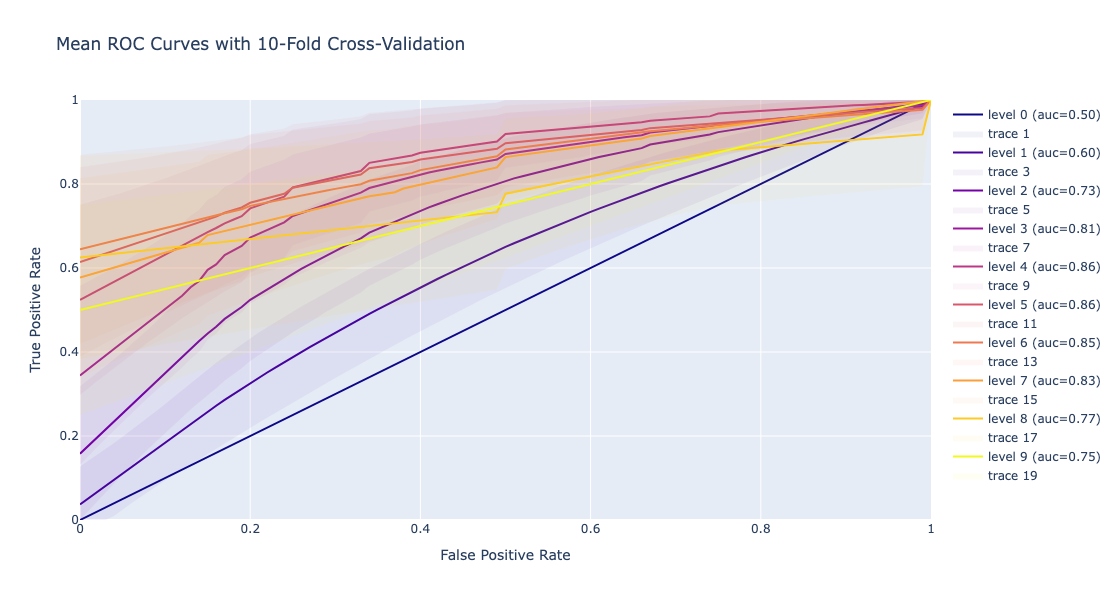

In [193]:
fig = go.Figure()

aucs_by_level = defaultdict(list)
colors = defaultdict(list)

cs = ['#0d0887', '#46039f', '#7201a8', '#9c179e', '#bd3786', '#d8576b', '#ed7953', '#fb9f3a', '#fdca26', '#f0f921']
ci = 0
for lvl in k_likelihoods_by_level_by_tree_by_person:

    # Store ROC values for each level to compute mean and thresholds
    tprs = []
    aucs = []
    mean_fpr = np.linspace(0, 1, 101)

    for tp_idx in range(len(k_likelihoods_by_level_by_tree_by_person[lvl])):
        this_level_this_tree_aucs = []
        for y_prob, y_test in zip(k_likelihoods_by_level_by_tree_by_person[lvl][tp_idx], 
                                  k_actual_accuracies_by_level_by_tree_by_person[lvl][tp_idx]):
        
            # gonna be illegal to do ROC
            if len(y_test) == 0 or len(set(y_test)) == 1:
                continue
    
            fpr, tpr, _ = roc_curve(y_test, y_prob)
            roc_auc = roc_auc_score(y_test, y_prob)
            aucs.append(roc_auc)
            this_level_this_tree_aucs.append(roc_auc)
    
            # Interpolate TPRs over the mean FPR
            tpr_interp = np.interp(mean_fpr, fpr, tpr)
            tprs.append(tpr_interp)

        if len(this_level_this_tree_aucs) > 0:
            aucs_by_level[lvl].append(np.mean(this_level_this_tree_aucs))
            colors[lvl].append(path_diffs_by_level[lvl][tp_idx])
    
    if len(tprs) == 0: continue

    # Calculate the mean and standard deviation of the TPRs
    mean_tpr = np.mean(tprs, axis=0)
    std_tpr = np.std(tprs, axis=0)

    # Calculate the upper and lower bounds of the shaded area (mean ± 1 std dev)
    tpr_upper = np.minimum(mean_tpr + .5*std_tpr, 1)
    tpr_lower = np.maximum(mean_tpr - .5*std_tpr, 0)   

    # print(mean_tpr)
    # print(mean_fpr)

    # Plot mean ROC curve
    fig.add_trace(go.Scatter(
        x=mean_fpr, y=mean_tpr,
        mode='lines',
        line=dict(color=cs[ci], width=2),
        name=f"level {lvl} (auc={np.mean(aucs):0.2f})"
    ))

    # Plot the shadow (error band)
    fig.add_trace(go.Scatter(
        x=np.concatenate([mean_fpr, mean_fpr[::-1]]),
        y=np.concatenate([tpr_upper, tpr_lower[::-1]]),
        fill='toself',
        opacity=0.05,
        fillcolor=cs[ci],
        line=dict(color='rgba(255,255,255,0)'),
        hoverinfo="skip",
        name='1 std dev'
    ))

    ci += 1

# Customize layout
fig.update_layout(
    title=f"Mean ROC Curves with {K_FOLD}-Fold Cross-Validation",
    xaxis_title="False Positive Rate",
    yaxis_title="True Positive Rate",
    xaxis=dict(range=[0, 1]),
    yaxis=dict(range=[0, 1]),
    showlegend=True,
    width=800,
    height=600
)
    
# Show plot
fig.show()

In [172]:
print([len(aucs_by_level[l]) for l in aucs_by_level])

[72, 72, 72, 71, 68, 65, 34, 15, 5, 1]


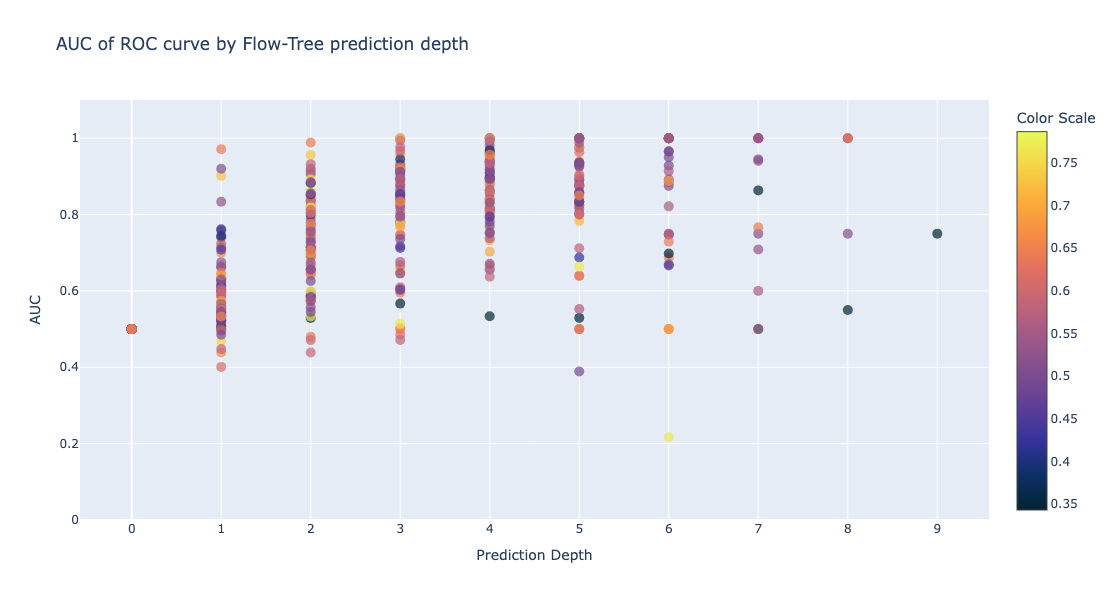

In [181]:

fig = go.Figure()

# Flatten the data for Plotly
xs = []
ys = []
cs = []

for lvl in aucs_by_level:
    xs.extend([lvl] * len(aucs_by_level[lvl]))  # Repeat level value
    ys.extend(aucs_by_level[lvl])               # Y values (AUCs)
    cs.extend(colors[lvl])                      # Color values (continuous scale)

# Scatter plot using Plotly with continuous color scale
fig.add_trace(go.Scatter(
    x=xs, y=ys,
    mode='markers',
    marker=dict(
        size=10,
        color=cs,              # Color based on the values in 'cs'
        colorscale='thermal',   # Choose a continuous color scale (e.g., Viridis)
        colorbar=dict(
            title="Color Scale"  # Title for the colorbar
        ),
        showscale=True,         # Show the color scale legend
        opacity=0.7
    )
))

# Customize the layout
fig.update_layout(
    title="AUC of ROC curve by Flow-Tree prediction depth",
    xaxis_title="Prediction Depth",
    yaxis_title="AUC",
    xaxis=dict(tickmode='linear'),
    yaxis=dict(range=[0, 1.1]),  # Adjust y-axis to fit AUC values
    width=800,
    height=600
)

# Show the plot
fig.show()

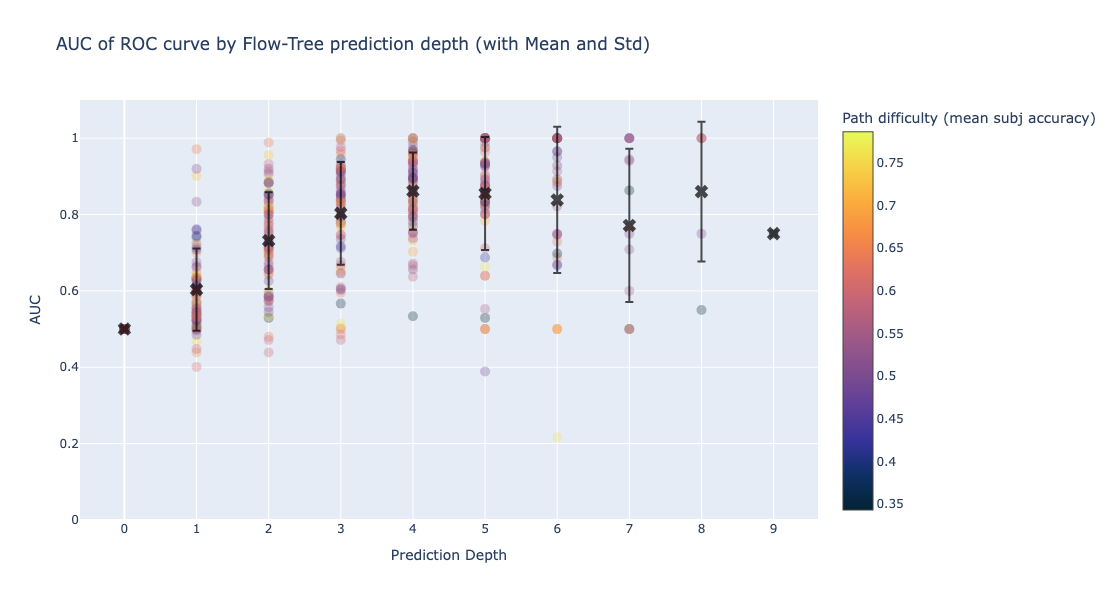

In [192]:
import plotly.graph_objects as go
import numpy as np

# Example structure for aucs_by_level and colors
# aucs_by_level = {1: [0.6, 0.7], 2: [0.8, 0.65], 3: [0.5, 0.55]}
# colors = {1: [0.55, 0.7], 2: [0.9, 0.6], 3: [0.4, 0.48]}

fig = go.Figure()

# Flatten the data for scatter plot
xs = []
ys = []
cs = []

# Calculate means and stds for each level
mean_xs = []
mean_ys = []
std_ys = []

for lvl in aucs_by_level:
    # Collect data for scatter
    xs.extend([lvl] * len(aucs_by_level[lvl]))  # Repeat level value
    ys.extend(aucs_by_level[lvl])               # Y values (AUCs)
    cs.extend(colors[lvl])                      # Color values (continuous scale)
    
    # Calculate mean and std for current level
    mean_xs.append(lvl)
    mean_ys.append(np.mean(aucs_by_level[lvl]))
    std_ys.append(np.std(aucs_by_level[lvl]))

# Scatter plot using Plotly with continuous color scale
fig.add_trace(go.Scatter(
    x=xs, y=ys,
    mode='markers',
    marker=dict(
        size=10,
        color=cs,              # Color based on the values in 'cs'
        colorscale='thermal',   # Choose a continuous color scale (e.g., Viridis)
        colorbar=dict(
            title="Path difficulty\n(mean subj accuracy)"  # Title for the colorbar
        ),
        showscale=True,         # Show the color scale legend
        opacity=0.3
    ),
    name='AUC Scatter'
))

# Add mean points with error bars for standard deviation
fig.add_trace(go.Scatter(
    x=mean_xs, y=mean_ys,
    mode='markers',
    opacity=0.7,
    error_y=dict(
        type='data',
        array=std_ys,  # Standard deviation
        visible=True
    ),
    marker=dict(
        size=12,
        color='black',
        symbol='x'  # Use 'x' symbol for the mean points
    ),
    # line=dict(dash='dash'),
    name='Mean AUC ± 1 std'
))

# Customize the layout
fig.update_layout(
    title="AUC of ROC curve by Flow-Tree prediction depth (with Mean and Std)",
    xaxis_title="Prediction Depth",
    yaxis_title="AUC",
    xaxis=dict(tickmode='linear'),
    yaxis=dict(range=[0, 1.1]),  # Adjust y-axis to fit AUC values
    showlegend=False,
    width=800,
    height=600
)

# Show the plot
fig.show()


## idk wtf this is, but don't wanna trash just yet

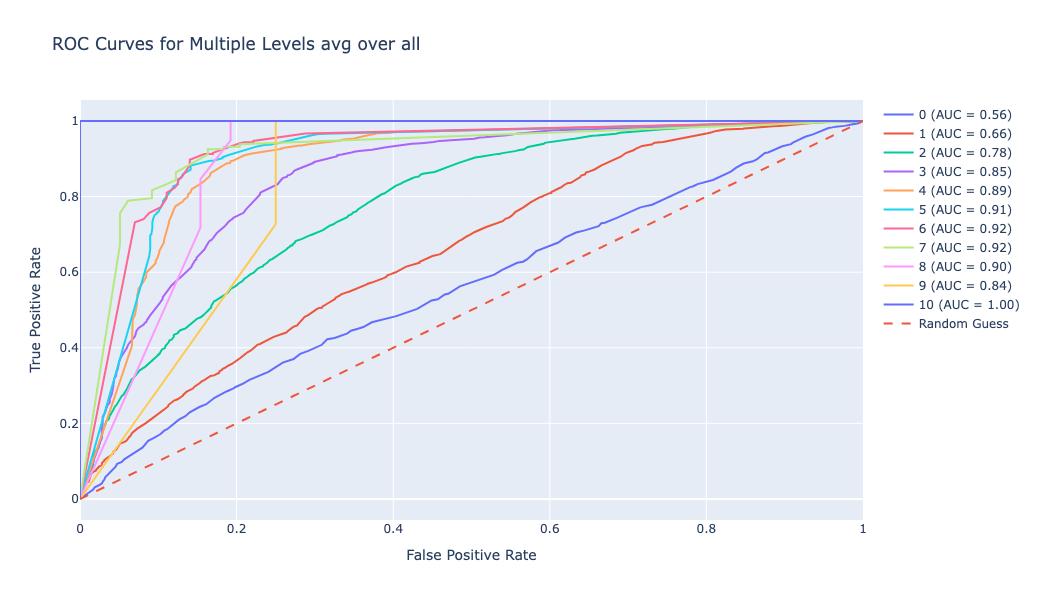

{0: [0.41894127377998347, 0.3388157894736842, 0.41331269349845207, 0.4277605779153767, 0.4602272727272727, 0.43401759530791784, 0.38596491228070173, 0.3733552631578947, 0.4411302982731554, 0.32800982800982803, 0.375, 0.3571428571428572, 0.37387387387387383, 0.3768939393939394, 0.3478260869565218, 0.42021276595744683, 0.41666666666666663, 0.42764857881136953, 0.4430091185410334, 0.3812121212121212, 0.41558441558441556, 0.38986013986013984, 0.40934320074005554, 0.3513071895424837, 0.4339430894308943, 0.41666666666666663, 0.404, 0.36424242424242426, 0.3776223776223776, 0.4257142857142857, 0.4155844155844156, 0.3794142980189492, 0.4746376811594203, 0.3506666666666667, 0.37941429801894927, 0.45333333333333325, 0.42533333333333334, 0.44210090984284534, 0.3412698412698413, 0.41600000000000004, 0.41216216216216217, 0.4642857142857143, 0.32867132867132864, 0.32732447817836813, 0.3912319644839068, 0.3824786324786325, 0.44819611470860315, 0.4366471734892787, 0.39705882352941174, 0.404545454545454

In [53]:
flow_trees = []

# Initialize a 12x6 grid for 72 subplots (12 columns and 6 rows)
rows = 6
cols = 12
total_plots = 72

# Create subplots with space for 72 ROC plots
sp_titles = []
for (start_node, end_node), group in test_df.groupby(["StartAt", "EndAt"]):
    sp_titles.append(f"{start_node} {end_node} {group['path_mean_acc'].iloc[0]:.2f}")
fig = make_subplots(rows=rows, cols=cols, subplot_titles=sp_titles)


count = 0
plot_xs = []
plot_ys = []
accs = {}
aucs_by_level = {}

all_likelihoods_by_level_by_person = {}
all_actual_accuracies_by_level_by_person = {}

for (start_node, end_node), group in test_df.groupby(["StartAt", "EndAt"]):
    this_path_df = df[(df["StartAt"] == start_node) & (df["EndAt"] == end_node)]


    # Calculate ROC and AUC for each model
    roc_data = {}
    px = []
    py = []

    likelihoods_by_level_by_person = {}
    actual_accuracies_by_level_by_person = {}

    # Do each Flow Tree k=5 times
    for k in range(5):
        train_this_path_df, test_this_path_df = train_test_split(this_path_df, test_size=0.2, random_state=k)
    
        # Identify where one person's path is through the Flow Tree
        for _, plus_one in test_this_path_df.iterrows():
            special_subject_number = plus_one["Subject"]
    
            train_this_path_df_plus_one = pd.concat([train_this_path_df, pd.DataFrame([plus_one])])
            G_plus_one, special_visits, likelihoods_by_level = track_indiv_through_flow_tree(train_this_path_df_plus_one, special_subject_number, use_turns=False, DEBUG=False)

            # Keep track of all of the predictions for all the levels
            actual_acc = int(plus_one["accuracy"])
            for j, lik in enumerate(likelihoods_by_level):
                if j in likelihoods_by_level_by_person:
                    likelihoods_by_level_by_person[j].append(lik)
                    actual_accuracies_by_level_by_person[j].append(actual_acc)
                else:
                    likelihoods_by_level_by_person[j] = [lik]
                    actual_accuracies_by_level_by_person[j] = [actual_acc]

                if j in all_likelihoods_by_level_by_person:
                    all_likelihoods_by_level_by_person[j].append(lik)
                    all_actual_accuracies_by_level_by_person[j].append(actual_acc)
                else:
                    all_likelihoods_by_level_by_person[j] = [lik]
                    all_actual_accuracies_by_level_by_person[j] = [actual_acc]

        # Compute ROC curve for ONE Flow Tree    
                
        fig = go.Figure()

    # print(all_actual_accuracies_by_level_by_person)

    # print("HI",[len(likelihoods_by_level_by_person[x]) for x in likelihoods_by_level_by_person])
    # break
    # print(likelihoods_by_level_by_person)
    # print(actual_accuracies_by_level_by_person)
    for i in likelihoods_by_level_by_person:
        # y_prob = []
        # this_y_test = []
        # for j, lik in likelihoods_by_level_by_person.items():
        #     if i < len(lik) and not pd.isna(lik[i]):
        #         y_prob.append(lik[i])
        #         this_y_test.append(y_test[j])
        # if len(this_y_test) == 0 or len(set(this_y_test)) == 1:
        #     continue
        # # print(this_y_test)
        # # print(y_prob)

        y_prob, this_y_test = [], []
        for x in range(len(likelihoods_by_level_by_person[i])):
            if not pd.isna(likelihoods_by_level_by_person[i][x]):
                y_prob.append(likelihoods_by_level_by_person[i][x])
                this_y_test.append(actual_accuracies_by_level_by_person[i][x])
        
        # print("YP", i, this_y_test, y_prob)

        # gonna be illegal to do ROC
        if len(this_y_test) == 0 or len(set(this_y_test)) == 1:
            continue

        fpr, tpr, _ = roc_curve(this_y_test, y_prob)
        auc = roc_auc_score(this_y_test, y_prob)
        roc_data[i] = (fpr, tpr, auc)

        px.append(i)
        py.append(auc)

        acc = group['path_mean_acc'].iloc[0]
        if i in aucs_by_level:
            aucs_by_level[i].append(auc)
            accs[i].append(acc)
        else:
            aucs_by_level[i] = [auc]            
            accs[i] = [acc]

        # print(fpr, tpr, auc)
        # print(len(this_y_test), np.mean(this_y_test))

    # print(aucs_by_level)
    # # break
    # plot_xs.append(aucs_by_level.keys())
    # plot_ys.append([np.mean(aucs_by_level[i]) for i in aucs_by_level])
    # accs.append(group['path_mean_acc'].iloc[0])
        
    # # # Create an interactive ROC plot using Plotly
    # # fig = go.Figure()
    # row = (count // cols) + 1
    # col = (count % cols) + 1

    # # Add ROC curves for each model
    # for model_name, (fpr, tpr, auc) in roc_data.items():
    #     fig.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name=f'{model_name} (AUC = {auc:.2f})'))#, row=row, col=col)    # Add ROC curves to the respective subplot
            
    
    # # Add a diagonal reference line (random guess line)
    # fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', line=dict(dash='dash'), name='Random Guess'))#, row=row, col=col)
    
    # # Customize the layout
    # fig.update_layout(
    #     title=f"ROC Curves for Multiple Levels {start_node} {end_node} {group['path_mean_acc'].iloc[0]:.2f}",
    #     xaxis_title='False Positive Rate',
    #     yaxis_title='True Positive Rate',
    #     showlegend=True,
    #     width=800,
    #     height=600
    # )
    
    # # Show the plot
    # fig.show()



    # count += 1
    # if count >5:
    #     # Now we need to do counts for each 
    #     break

# fig.update_layout(height=1500, width=3000, title_text="72 ROC Curves in Subplots", showlegend=False)
# fig.show()

for i in all_likelihoods_by_level_by_person:
    # y_prob = []
    # this_y_test = []
    # for j, lik in likelihoods_by_level_by_person.items():
    #     if i < len(lik) and not pd.isna(lik[i]):
    #         y_prob.append(lik[i])
    #         this_y_test.append(y_test[j])
    # if len(this_y_test) == 0 or len(set(this_y_test)) == 1:
    #     continue
    # # print(this_y_test)
    # # print(y_prob)

    y_prob, this_y_test = [], []
    for x in range(len(all_likelihoods_by_level_by_person[i])):
        if not pd.isna(all_likelihoods_by_level_by_person[i][x]):
            y_prob.append(all_likelihoods_by_level_by_person[i][x])
            this_y_test.append(all_actual_accuracies_by_level_by_person[i][x])
    
    # print("YP", i, this_y_test, y_prob)

    # gonna be illegal to do ROC
    if len(this_y_test) == 0 or len(set(this_y_test)) == 1:
        continue

    fpr, tpr, _ = roc_curve(this_y_test, y_prob)
    auc = roc_auc_score(this_y_test, y_prob)
    roc_data[i] = (fpr, tpr, auc)

    px.append(i)
    py.append(auc)

    acc = group['path_mean_acc'].iloc[0]
    if i in aucs_by_level:
        aucs_by_level[i].append(auc)
        accs[i].append(acc)
    else:
        aucs_by_level[i] = [auc]   
        accs[i] = [acc]

    # print(fpr, tpr, auc)
    # print(len(this_y_test), np.mean(this_y_test))

# print(aucs_by_level)
# break
plot_xs.append(aucs_by_level.keys())
plot_ys.append([np.mean(aucs_by_level[i]) for i in aucs_by_level])
    
# # Create an interactive ROC plot using Plotly
# fig = go.Figure()
row = (count // cols) + 1
col = (count % cols) + 1

# Add ROC curves for each model
for model_name, (fpr, tpr, auc) in roc_data.items():
    fig.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name=f'{model_name} (AUC = {auc:.2f})'))#, row=row, col=col)    # Add ROC curves to the respective subplot
        

# Add a diagonal reference line (random guess line)
fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', line=dict(dash='dash'), name='Random Guess'))#, row=row, col=col)

# Customize the layout
fig.update_layout(
    title=f"ROC Curves for Multiple Levels avg over all",
    xaxis_title='False Positive Rate',
    yaxis_title='True Positive Rate',
    showlegend=True,
    width=800,
    height=600
)

# Show the plot
fig.show()

print(aucs_by_level)
print(accs)